<a href="https://colab.research.google.com/github/ZhehanWira/TugasDataWira/blob/main/E_Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Persiapan Library & Data**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from scipy.stats import ttest_ind

df = pd.read_csv('data.csv')
df.head()

,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0


### **Inspeksi & Pembersihan Data (Data Cleaning)**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    int64  
 1   CustomerID        150 non-null    int64  
 2   Order_Date        150 non-null    object 
 3   Product_Category  150 non-null    object 
 4   Quantity          150 non-null    int64  
 5   Price_Per_Unit    150 non-null    float64
 6   Ad_Budget         150 non-null    float64
 7   Total_Sales       143 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 9.5+ KB


In [ ]:
df.isnull().sum()

,0
Order_ID,0
CustomerID,0
Order_Date,0
Product_Category,0
Quantity,0
Price_Per_Unit,0
Ad_Budget,0
Total_Sales,7


In [ ]:
df = df[df['Price_Per_Unit'] > 0]
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

### **Analisis Tren Penjualan Bulanan (Line Chart)**

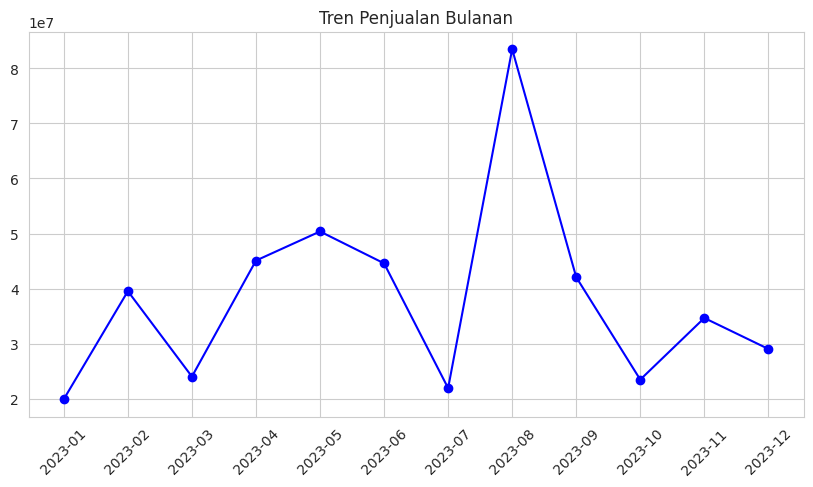

In [ ]:
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b')
plt.title('Tren Penjualan Bulanan')
plt.xticks(rotation=45)
plt.show()

### **Analisis Korelasi (Heatmap)**

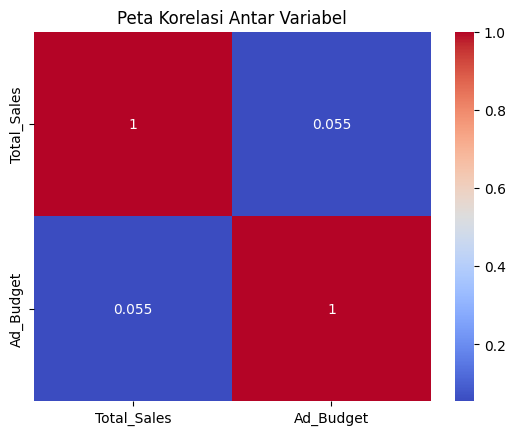

In [ ]:
correlation = df[['Total_Sales', 'Ad_Budget']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()

# **Tugas Siswa (Kelompok Sebangku)**

## **1. Identifikasi Produk &quot;Underperformer&quot;**

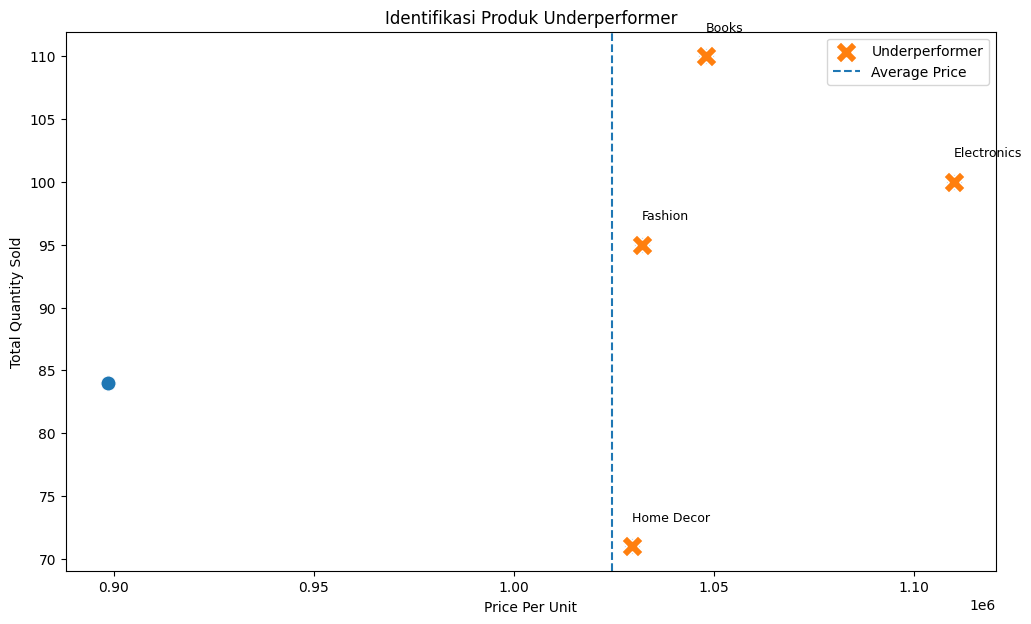

In [8]:
# =========================
# Analisis Underperformer
# =========================

# rata-rata harga produk
avg_price = df["Price_Per_Unit"].mean()

# group per produk
product_perf = df.groupby("Product_Category").agg({
    "Price_Per_Unit": "mean",
    "Quantity": "sum",
    "Total_Sales": "sum"
}).reset_index()

# filter:
# harga > rata-rata
# quantity kecil
underperformer = product_perf[
    product_perf["Price_Per_Unit"] > avg_price
].sort_values("Quantity", ascending=True)


# =========================
# Scatter Plot
# =========================
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=product_perf,
    x="Price_Per_Unit",
    y="Quantity",
    s=120
)

# highlight underperformer
sns.scatterplot(
    data=underperformer.head(5),
    x="Price_Per_Unit",
    y="Quantity",
    s=250,
    marker="X",
    label="Underperformer"
)

# label nama produk
for _, row in underperformer.head(5).iterrows():
    plt.text(
        row["Price_Per_Unit"] + 2,
        row["Quantity"] + 2,
        row["Product_Category"],
        fontsize=9
    )

# garis rata-rata harga
plt.axvline(
    avg_price,
    linestyle="--",
    label="Average Price"
)

plt.title("Identifikasi Produk Underperformer")
plt.xlabel("Price Per Unit")
plt.ylabel("Total Quantity Sold")
plt.legend()
plt.show()

## **2. Segmentasi Pelanggan (RFM Analysis)**

In [9]:
# ====================================
# RFM ANALYSIS
# ====================================

# tanggal acuan = sehari setelah transaksi terakhir
snapshot_date = df["Order_Date"].max() + dt.timedelta(days=1)

# hitung RFM
rfm = df.groupby("CustomerID").agg({
    "Order_Date": lambda x: (snapshot_date - x.max()).days,
    "Order_ID": "count",
    "Total_Sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print("=== DATA RFM ===")
print(rfm.head())


# ====================================
# SCORING 1–5
# ====================================

# Recency makin kecil makin bagus
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

# Frequency makin besar makin bagus
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

# Monetary makin besar makin bagus
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)
rfm["Monetary"] = rfm["Monetary"].astype(int)

# gabung skor
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int) +
    rfm["F_Score"].astype(int) +
    rfm["M_Score"].astype(int)
)

print("")

# ====================================
# SEGMENTASI
# ====================================

def segment_customer(row):
    score = (
        int(row["R_Score"]) +
        int(row["F_Score"]) +
        int(row["M_Score"])
    )

    if score >= 13:
        return "Mendapatkan Voucher Loyalitas"
    else:
        return "Tidak Mendapatkan Voucher Loyalitas"




rfm["Segment"] = rfm.apply(segment_customer, axis=1)

# SORT: score tertinggi di atas
rfm = rfm.sort_values(
    by="RFM_Score",
    ascending=False
)

print("\n=== HASIL SEGMENTASI CUSTOMER ===")
print(
    rfm.head(10)[
        ["Segment"]
    ]
)

TypeError: can only concatenate str (not "datetime.timedelta") to str

## **3. Analisis Kontribusi Kategori**

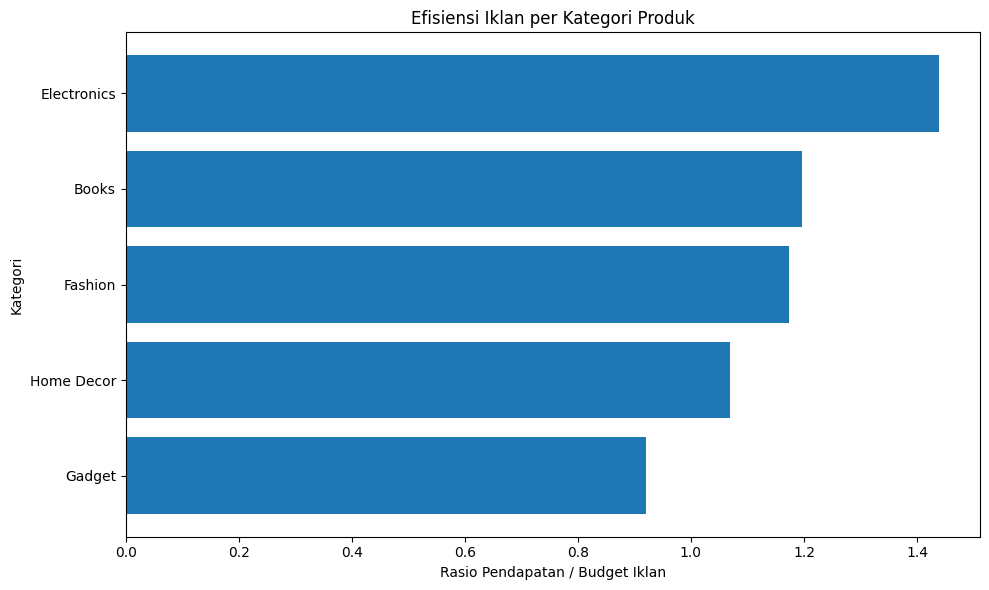

In [ ]:
category_eff = df.groupby("Product_Category").agg({
    "Total_Sales": "sum",
    "Ad_Budget": "sum"
}).reset_index()

# hitung efisiensi
category_eff["Efficiency"] = (
    category_eff["Total_Sales"] /
    category_eff["Ad_Budget"]
)

# urutkan dari paling tidak efisien
category_eff = category_eff.sort_values(
    by="Efficiency",
    ascending=True
)

# ====================================
# VISUALISASI
# ====================================

plt.figure(figsize=(10,6))

plt.barh(
    category_eff["Product_Category"],
    category_eff["Efficiency"]
)

plt.title("Efisiensi Iklan per Kategori Produk")
plt.xlabel("Rasio Pendapatan / Budget Iklan")
plt.ylabel("Kategori")

plt.tight_layout()
plt.show()

## **4. Uji Hipotesis Sederhana**

In [7]:
# ====================================
# UJI HIPOTESIS IKLAN
# ====================================

# median budget iklan
median_budget = df["Ad_Budget"].median()

# kelompokkan
high_ads = df[df["Ad_Budget"] > median_budget].dropna(subset=['Total_Sales'])
low_ads = df[df["Ad_Budget"] <= median_budget].dropna(subset=['Total_Sales'])

# rata-rata sales
mean_high = high_ads["Total_Sales"].mean()
mean_low = low_ads["Total_Sales"].mean()

print("Median Ad Budget:", median_budget)
print("Rata-rata Sales (Iklan Tinggi):", round(mean_high,2))
print("Rata-rata Sales (Iklan Rendah):", round(mean_low,2))

# Perform independent samples t-test
t_stat, p_value = ttest_ind(high_ads['Total_Sales'], low_ads['Total_Sales'], equal_var=False) # Use Welch's t-test if variances are not assumed to be equal

print(f"\nT-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.3f}")

# interpretasi
alpha = 0.05

if p_value < alpha:
    print("\nKesimpulan: Ada pengaruh signifikan Ad_Budget terhadap Total_Sales")
else:
    print("\nKesimpulan: Tidak ada pengaruh signifikan Ad_Budget terhadap Total_Sales")

Median Ad Budget: 2722500.0
Rata-rata Sales (Iklan Tinggi): 3156275.36
Rata-rata Sales (Iklan Rendah): 3247216.22

T-statistic: -0.22
P-value: 0.829

Kesimpulan: Tidak ada pengaruh signifikan Ad_Budget terhadap Total_Sales
